<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/dynamicPricing/DynamicPricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

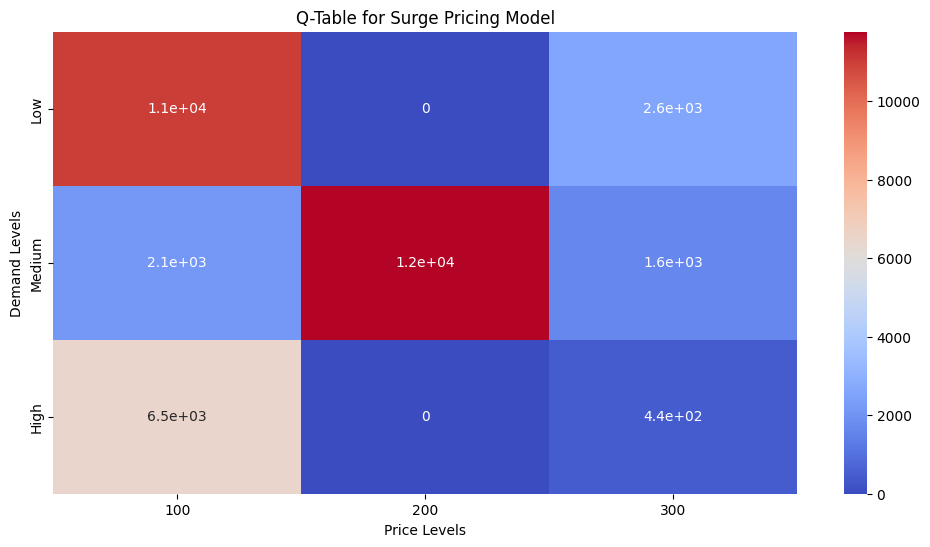

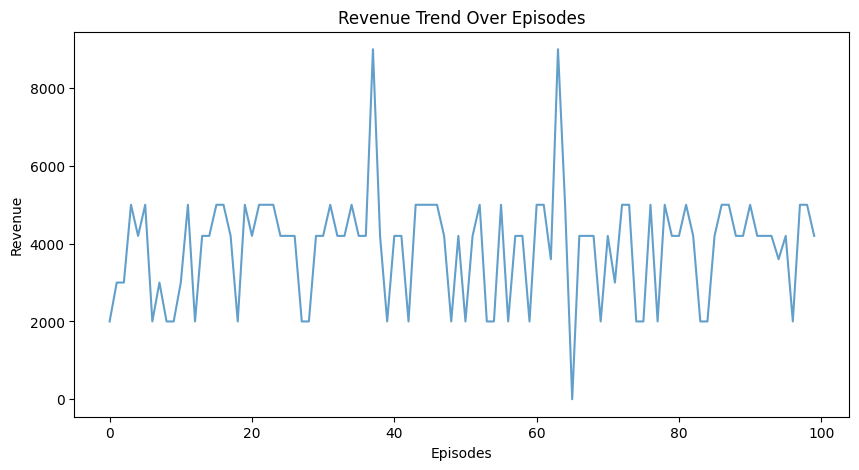

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Environment settings
demand_levels = ["Low", "Medium", "High"]
price_levels = [100, 200, 300]  # Possible surge pricing levels

# Q-table initialization
q_table = np.zeros((len(demand_levels), len(price_levels)))

# Hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.1  # Exploration rate

def get_reward(demand_state, price_action):
    """Simulates the revenue as a reward function."""
    base_demand = [50, 30, 20]  # Base demand at normal price
    price_sensitivity = [-0.2, -0.3, -0.5]  # Demand reduction factor per price increase

    demand = base_demand[demand_state] * (1 + price_sensitivity[demand_state] * (price_action / 100 - 1))
    revenue = demand * price_action
    return revenue

def select_action(state):
    """Epsilon-greedy action selection."""
    if np.random.rand() < epsilon:
        return np.random.choice(len(price_levels))
    else:
        return np.argmax(q_table[state])

# Training the agent
episodes = 100
rewards = []

for _ in range(episodes):
    state = np.random.choice(len(demand_levels))
    action = select_action(state)

    reward = get_reward(state, price_levels[action])
    next_state = np.random.choice(len(demand_levels))  # Demand fluctuates randomly

    # Q-learning update
    q_table[state, action] = q_table[state, action] + alpha * (
        reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
    )

    rewards.append(reward)

# Visualization
plt.figure(figsize=(12, 6))
sns.heatmap(q_table, annot=True, cmap="coolwarm", xticklabels=price_levels, yticklabels=demand_levels)
plt.xlabel("Price Levels")
plt.ylabel("Demand Levels")
plt.title("Q-Table for Surge Pricing Model")
plt.show()

# Plot rewards trend
plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.7)
plt.xlabel("Episodes")
plt.ylabel("Revenue")
plt.title("Revenue Trend Over Episodes")
plt.show()

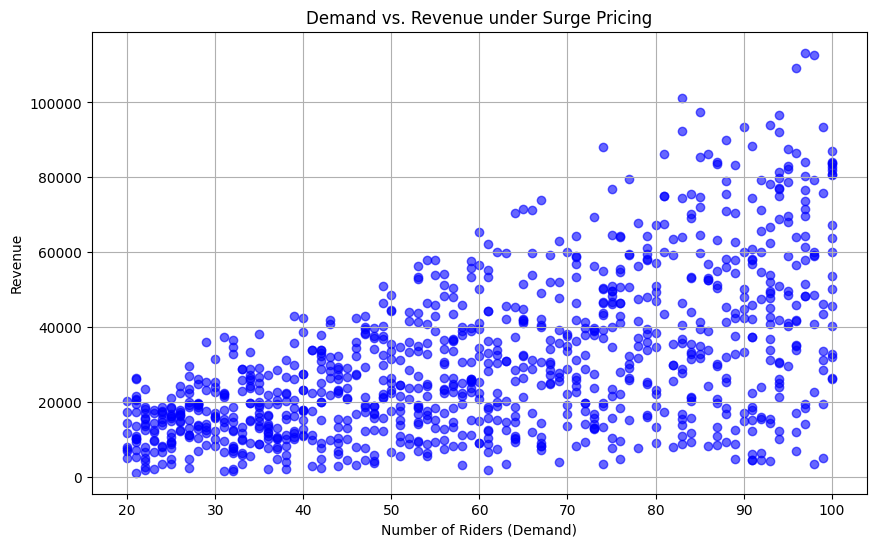

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = "dynamic_pricing.csv"
df = pd.read_csv(file_path)

# Define surge multiplier based on demand-supply ratio
def calculate_surge(row):
    demand_supply_ratio = row['Number_of_Riders'] / row['Number_of_Drivers']

    if demand_supply_ratio > 2:
        return 1.5  # High surge
    elif demand_supply_ratio > 1.5:
        return 1.3  # Medium surge
    elif demand_supply_ratio > 1.2:
        return 1.1  # Low surge
    else:
        return 1.0  # No surge

# Apply surge pricing
df["Surge_Multiplier"] = df.apply(calculate_surge, axis=1)

# Calculate Surge Price
df["Surge_Price"] = df["Historical_Cost_of_Ride"] * df["Surge_Multiplier"]

# Estimate Revenue (Revenue = Surge Price * Number of Rides)
df["Revenue"] = df["Surge_Price"] * df["Number_of_Riders"]

# Plot Demand vs Revenue
plt.figure(figsize=(10, 6))
plt.scatter(df["Number_of_Riders"], df["Revenue"], color='b', alpha=0.6)
plt.xlabel("Number of Riders (Demand)")
plt.ylabel("Revenue")
plt.title("Demand vs. Revenue under Surge Pricing")
plt.grid(True)
plt.show()


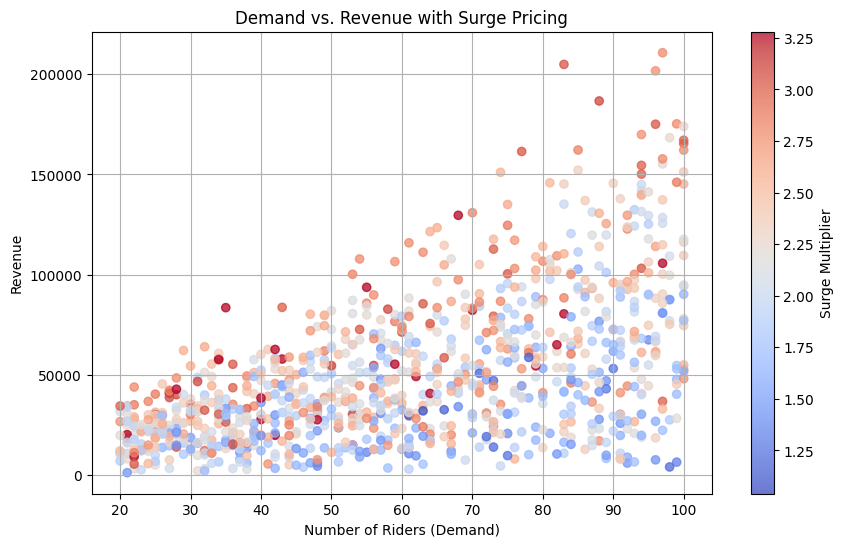

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = "dynamic_pricing.csv"
df = pd.read_csv(file_path)

# Define surge pricing model using multiple variables
def calculate_surge(row):
    demand_supply_ratio = row['Number_of_Riders'] / row['Number_of_Drivers']
    surge = 1.0  # Base multiplier

    # Demand-Supply Impact
    if demand_supply_ratio > 2:
        surge *= 1.5
    elif demand_supply_ratio > 1.5:
        surge *= 1.3
    elif demand_supply_ratio > 1.2:
        surge *= 1.1

    # Location Impact
    location_factor = {"Urban": 1.2, "Suburban": 1.1, "Rural": 1.0}
    surge *= location_factor.get(row['Location_Category'], 1.0)

    # Time of Booking Impact (Peak Hours Surge)
    peak_hours = {"Morning": 1.2, "Evening": 1.3, "Night": 1.4}
    surge *= peak_hours.get(row['Time_of_Booking'], 1.0)

    # Vehicle Type Impact
    vehicle_factor = {"Premium": 1.3, "Economy": 1.1}
    surge *= vehicle_factor.get(row['Vehicle_Type'], 1.0)

    # Customer Loyalty Discount (Higher loyalty status = Lower surge)
    loyalty_discount = {"Platinum": 0.9, "Gold": 0.95, "Silver": 1.0, "Bronze": 1.05}
    surge *= loyalty_discount.get(row['Customer_Loyalty_Status'], 1.0)

    return round(surge, 2)

# Apply surge pricing calculations
df["Surge_Multiplier"] = df.apply(calculate_surge, axis=1)

# Calculate Surge Price
df["Surge_Price"] = df["Historical_Cost_of_Ride"] * df["Surge_Multiplier"]

# Estimate Revenue (Revenue = Surge Price * Number of Riders)
df["Revenue"] = df["Surge_Price"] * df["Number_of_Riders"]

# Plot Demand vs Revenue
plt.figure(figsize=(10, 6))
plt.scatter(df["Number_of_Riders"], df["Revenue"], c=df["Surge_Multiplier"], cmap="coolwarm", alpha=0.75)
plt.colorbar(label="Surge Multiplier")
plt.xlabel("Number of Riders (Demand)")
plt.ylabel("Revenue")
plt.title("Demand vs. Revenue with Surge Pricing")
plt.grid(True)
plt.show()


<ipython-input-5-430162374ae2>:71: PerformanceWarning: indexing past lexsort depth may impact performance.
  q_table.loc[state, action] = max(q_table.loc[state, action], reward)
<ipython-input-5-430162374ae2>:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25583.154571969404' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  q_table.loc[state, action] = max(q_table.loc[state, action], reward)
<ipython-input-5-430162374ae2>:71: PerformanceWarning: indexing past lexsort depth may impact performance.
  q_table.loc[state, action] = max(q_table.loc[state, action], reward)
<ipython-input-5-430162374ae2>:71: PerformanceWarning: indexing past lexsort depth may impact performance.
  q_table.loc[state, action] = max(q_table.loc[state, action], reward)
<ipython-input-5-430162374ae2>:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an erro


Q-Table for Surge Pricing:

                                           1.0          1.1           1.2  \
Demand Supply Location Time                                                 
High   High   Urban    Night      76288.228435      0.00000      0.000000   
                       Evening    69594.330236      0.00000      0.000000   
                       Afternoon  55822.864570      0.00000  71012.266371   
                       Morning    62249.143041      0.00000      0.000000   
              Suburban Night      71185.896617      0.00000      0.000000   
...                                        ...          ...           ...   
Low    Low    Suburban Morning    34283.484678      0.00000      0.000000   
              Rural    Night      26535.178902      0.00000      0.000000   
                       Evening    30912.183457      0.00000      0.000000   
                       Afternoon      0.000000  14024.50228      0.000000   
                       Morning    28646.679897 

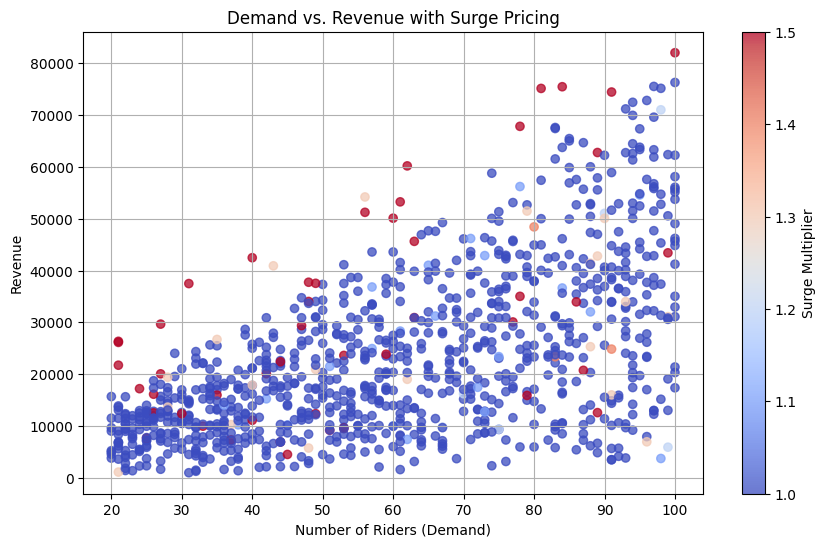

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = "dynamic_pricing.csv"
df = pd.read_csv(file_path)

# Define states (discretized categories)
def get_demand_category(demand):
    return "High" if demand > 80 else "Medium" if demand > 50 else "Low"

def get_supply_category(supply):
    return "High" if supply > 40 else "Medium" if supply > 30 else "Low"

df["Demand_Category"] = df["Number_of_Riders"].apply(get_demand_category)
df["Supply_Category"] = df["Number_of_Drivers"].apply(get_supply_category)

# Define surge multipliers (ensure these values match exactly)
surge_multipliers = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
surge_multipliers_str = [str(m) for m in surge_multipliers]  # Convert to string for column names

# Initialize Q-table
q_table = pd.DataFrame(0, index=pd.MultiIndex.from_product(
    [df["Demand_Category"].unique(), df["Supply_Category"].unique(),
     df["Location_Category"].unique(), df["Time_of_Booking"].unique()],
    names=["Demand", "Supply", "Location", "Time"]
), columns=surge_multipliers_str)

# Surge Pricing Function
def calculate_surge(row):
    demand_supply_ratio = row['Number_of_Riders'] / row['Number_of_Drivers']
    surge = 1.0

    if demand_supply_ratio > 2:
        surge = 1.5
    elif demand_supply_ratio > 1.5:
        surge = 1.3
    elif demand_supply_ratio > 1.2:
        surge = 1.1

    # Location impact
    location_factor = {"Urban": 1.2, "Suburban": 1.1, "Rural": 1.0}
    surge *= location_factor.get(row['Location_Category'], 1.0)

    # Time impact
    peak_hours = {"Morning": 1.2, "Evening": 1.3, "Night": 1.4}
    surge *= peak_hours.get(row['Time_of_Booking'], 1.0)

    # Ensure surge is within the defined multipliers range
    surge = round(surge, 2)
    if surge not in surge_multipliers:
        surge = 1.0  # Default surge if it's out of expected range

    return str(surge)  # Convert to string for Q-table consistency

# Apply Surge Pricing
df["Surge_Multiplier"] = df.apply(calculate_surge, axis=1)

# Compute Revenue
df["Surge_Price"] = df["Historical_Cost_of_Ride"] * df["Surge_Multiplier"].astype(float)
df["Revenue"] = df["Surge_Price"] * df["Number_of_Riders"]

# Update Q-table with revenue as reward
for _, row in df.iterrows():
    state = (row["Demand_Category"], row["Supply_Category"], row["Location_Category"], row["Time_of_Booking"])
    action = row["Surge_Multiplier"]  # Now it's a string
    reward = row["Revenue"]

    # Assign revenue to Q-table (use max to keep best value)
    q_table.loc[state, action] = max(q_table.loc[state, action], reward)

# Display Q-table
print("\nQ-Table for Surge Pricing:\n")
print(q_table)

# Plot Demand vs Revenue
plt.figure(figsize=(10, 6))
plt.scatter(df["Number_of_Riders"], df["Revenue"], c=df["Surge_Multiplier"].astype(float), cmap="coolwarm", alpha=0.75)
plt.colorbar(label="Surge Multiplier")
plt.xlabel("Number of Riders (Demand)")
plt.ylabel("Revenue")
plt.title("Demand vs. Revenue with Surge Pricing")
plt.grid(True)
plt.show()
